Hey everyone, this is my first time participating in a kaggle competion, I am looking forward to learning a lot about machine learning and deep learning. Any comments and suggestions would be appreciated.

Current version: Data Import, preprocessing, and Binary Mask Generation

In [1]:
# imports
import glob
import os
import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import cv2
from scipy.ndimage import label

In [3]:
BASE_DIR = "data/"

In [4]:
# train = glob.glob("/kaggle/input/hubmap-hacking-the-human-vasculature/train/*")
# test = glob.glob("/kaggle/input/hubmap-hacking-the-human-vasculature/test/*")

train = glob.glob(f"{BASE_DIR}/train/*")
test = glob.glob(f"{BASE_DIR}/test/*")

In [5]:
# Create a dictionary to hold the annotations for each image
annotations = {}

# Open the annotations file
with open(f'{BASE_DIR}/polygons.jsonl', 'r') as f:
    # For each line in the file
    for line in f:
        # Parse the line as JSON
        annotation = json.loads(line)

        # Get the image ID and the list of annotations for this image
        image_id = annotation['id']
        image_annotations = annotation['annotations']

        # Store the annotations in the dictionary
        annotations[image_id] = image_annotations

In [6]:
# map images to json annotations
image_map = {impath.split('/')[-1].split('.')[0]: impath for impath in train}
image_map.update({impath.split('/')[-1].split('.')[0]: impath for impath in test})

**Preprocess Image**

This is still a work in progress, and right now no real preprocessing is being done. This is created here for future work and experimentation 

I have been experimenting with stain normalization that can be refrenced here [Staintool](http://https://www.kaggle.com/competitions/hubmap-hacking-the-human-vasculature/discussion/412396) but i am having issues running it in kaggle kernel. works fine in colab and local, The needed libraries are not included in kaggle kernel.

so right now it only converts to rgb and normalizes the images to 0-1

In [7]:
def preprocess_image(image):
    # Convert the image from BGR to RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize image
    image_resized = cv2.resize(image_rgb, (512 , 512))

    return image_resized

In [8]:
preprocessed_images = {}
for i, image_id in enumerate(list(annotations.keys())):
    # Open the image file
    if image_id in image_map:
        image = cv2.imread(image_map[image_id])
        preprocessed_image = preprocess_image(image.copy())
        
        # Normalize image to 0-1
        preprocessed_image_normalized = preprocessed_image / 255.0

        preprocessed_images[image_id] = preprocessed_image_normalized

#         # For the first 5 images, display the original and preprocessed image side by side
#         if i < 5:
#             plt.figure(figsize=(10, 5))

#             plt.subplot(1, 2, 1)
#             plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
#             plt.title("Original Image")
#             plt.axis('off')

#             plt.subplot(1, 2, 2)
#             plt.imshow(preprocessed_image_normalized)
#             plt.title("Preprocessed Image")
#             plt.axis('off')

#             plt.show()

Create binary masks, display results for first 5

In [9]:
def display_images_masks_overlays(image, masks, image_id):
    overlay = image.copy()
    colors = [(0, 255, 0), (255, 0, 0), (0, 0, 255)]  # colors for blood vessels, glomerulus and unsure respectively

    # Initialize dictionary to hold annotation counts
    annotation_counts = {}
    
    for idx, (annotation_type, mask) in enumerate(masks[image_id].items(), 2):
        # Count the number of distinct areas in the mask
        labeled, num_areas = label(mask)
        annotation_counts[annotation_type] = num_areas

        # update overlay
        overlay[mask > 0] = colors[idx-2]

    # print annotation counts
    print(f"Annotation counts for image {image_id}: {annotation_counts}")

    # prepare for subplot
    plt.figure(figsize=(25,5))

    # plot the original image
    plt.subplot(1,5,1)
    plt.imshow(image)
    plt.title('Image')
    plt.axis('off')
    
    for idx, (annotation_type, mask) in enumerate(masks[image_id].items(), 2):
        # plot the binary masks
        plt.subplot(1,5,idx)
        plt.imshow(mask, cmap='gray')
        plt.title(f'{annotation_type} mask')
        plt.axis('off')

    # plot the overlay
    plt.subplot(1,5,5)
    plt.imshow(image)  # Use RGB image
    plt.imshow(overlay, alpha=0.4)  # change alpha to adjust transparency
    plt.title('Overlay')
    plt.axis('off')
    plt.show()

In [14]:
# annotations.keys()

In [12]:
len(annotations.keys()) #檔案名稱 dict_keys(['0006ff2aa7cd', '00168d1b7522', '0033bbc76b6b', ...

1633

In [ ]:
"""this code take whole dataset, but we just want to show first 5 image."""

# %%time

# masks = {}
# annotation_types = ['blood_vessel', 'glomerulus', 'unsure']
# for image_id in annotations.keys():
#     if image_id in preprocessed_images:
#         polygons = annotations[image_id]
#         # Load the preprocessed image
#         image = preprocessed_images[image_id]

#         # Create an empty mask of the same size as the image
#         masks[image_id] = {annotation_type: np.zeros(image.shape[:2], dtype=np.uint8) for annotation_type in annotation_types}

#         # For each polygon
#         for polygon in polygons:
#             annotation_type = polygon['type']
#             lines = np.array(polygon['coordinates'])
#             lines = lines.reshape(-1, 1, 2)
#             # Draw the polygon on the mask
#             cv2.fillPoly(masks[image_id][annotation_type], [lines], 255)

#         # Display the image and its masks if it's one of the first 5 images
#         if len(masks) <= 5:
#             display_images_masks_overlays(image, masks, image_id)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Annotation counts for image 0006ff2aa7cd: {'blood_vessel': 8, 'glomerulus': 1, 'unsure': 0}


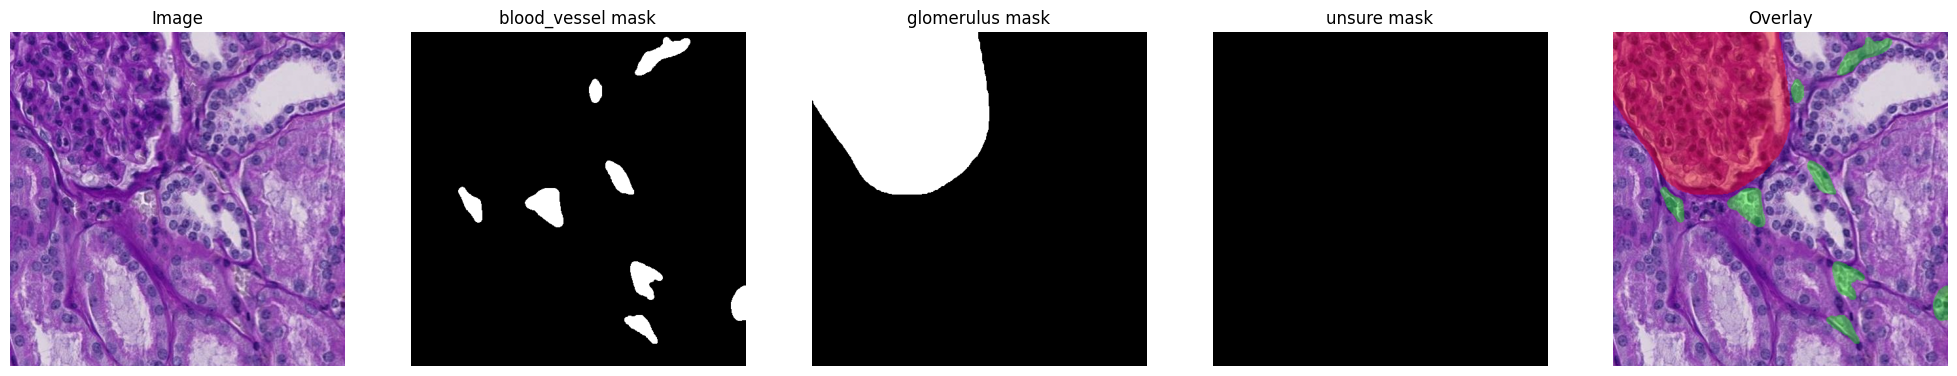

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Annotation counts for image 00168d1b7522: {'blood_vessel': 1, 'glomerulus': 1, 'unsure': 0}


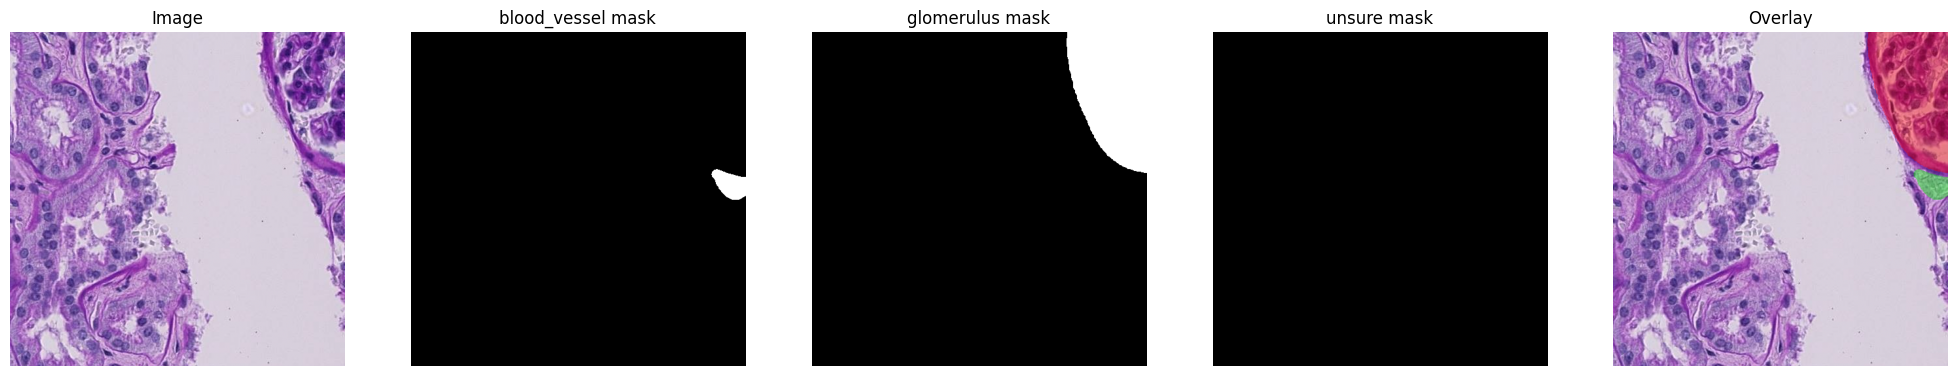

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Annotation counts for image 0033bbc76b6b: {'blood_vessel': 3, 'glomerulus': 0, 'unsure': 1}


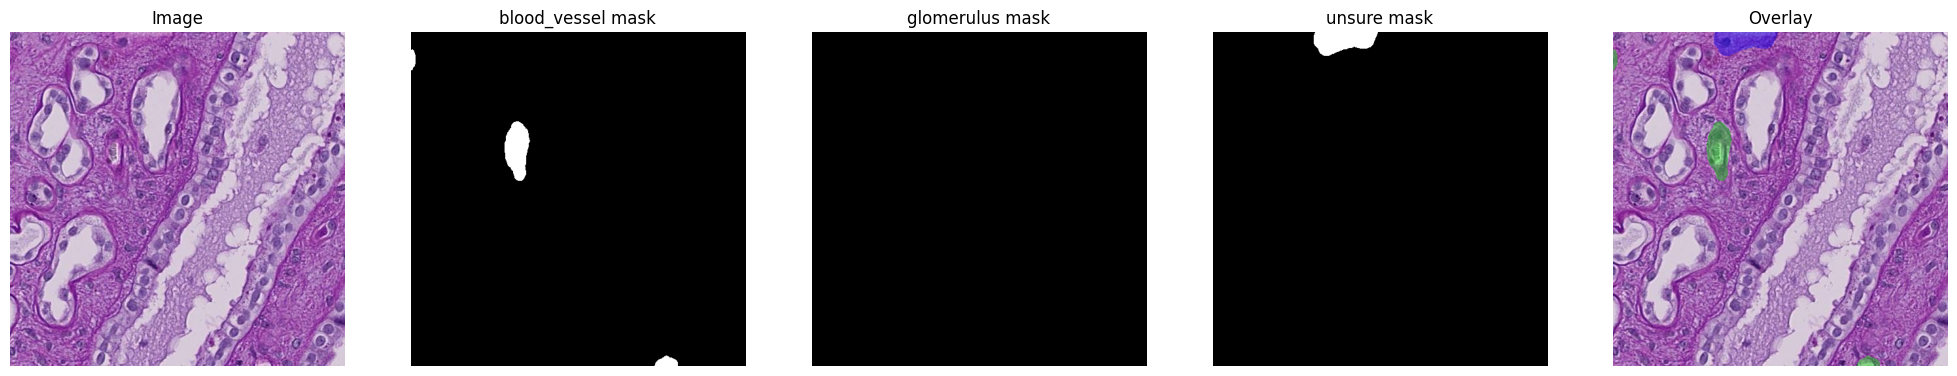

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Annotation counts for image 003504460b3a: {'blood_vessel': 7, 'glomerulus': 0, 'unsure': 0}


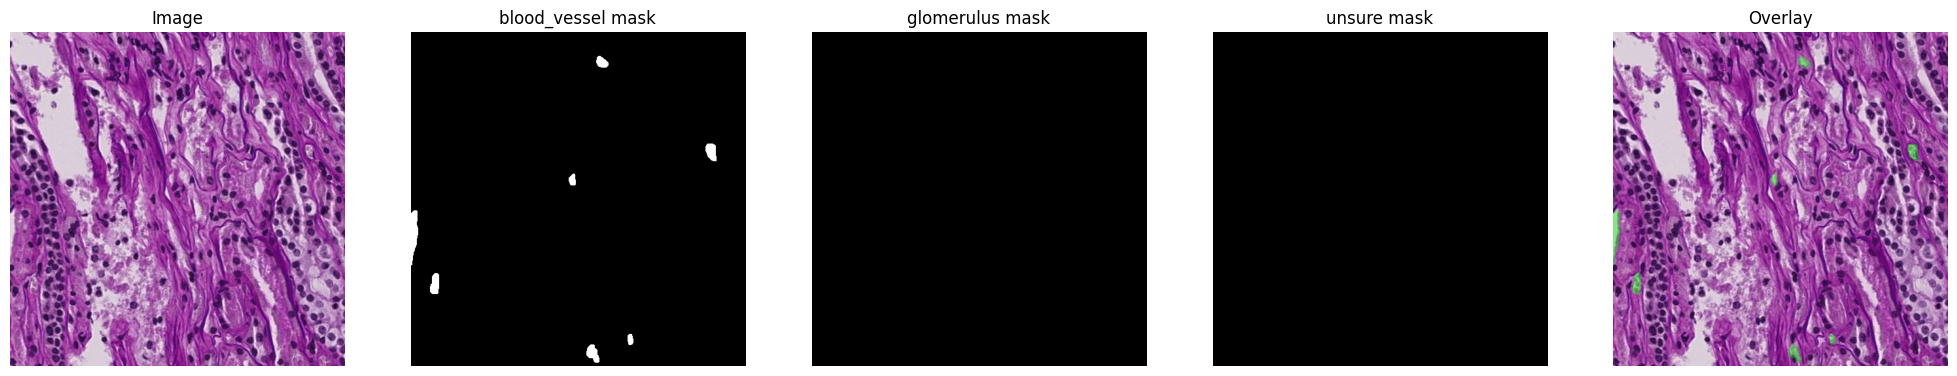

CPU times: user 1.75 s, sys: 469 ms, total: 2.22 s
Wall time: 1.5 s


In [25]:
%%time
"""So, we change the a little.
just do first 5 item: list(annotations.keys())[:4]
"""

masks = {}
annotation_types = ['blood_vessel', 'glomerulus', 'unsure']
for image_id in list(annotations.keys())[:4]:
    if image_id in preprocessed_images:
        polygons = annotations[image_id]
        # Load the preprocessed image
        image = preprocessed_images[image_id]

        # Create an empty mask of the same size as the image
        masks[image_id] = {annotation_type: np.zeros(image.shape[:2], dtype=np.uint8) for annotation_type in annotation_types}

        # For each polygon
        for polygon in polygons:
            annotation_type = polygon['type']
            lines = np.array(polygon['coordinates'])
            lines = lines.reshape(-1, 1, 2)
            # Draw the polygon on the mask
            cv2.fillPoly(masks[image_id][annotation_type], [lines], 255)

        # Display the image and its masks if it's one of the first 5 images
        if len(masks) <= 5:
            display_images_masks_overlays(image, masks, image_id)